# Car performance analysis using the mtcars datasets

# Part 1 (Load and understand the data)

In [1]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
from pydataset import data

In [5]:
# Display the first five rows
df = data('mtcars')
df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [6]:
# Shape of the dataset
df.shape

(32, 11)

In [7]:
# Column names
df.columns

Index(['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear',
       'carb'],
      dtype='object')

In [8]:
# Data types
df.dtypes

mpg     float64
cyl       int64
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs        int64
am        int64
gear      int64
carb      int64
dtype: object

In [9]:
# Summary statistics
df.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [10]:
# Missing values
df.isnull().sum()

mpg     0
cyl     0
disp    0
hp      0
drat    0
wt      0
qsec    0
vs      0
am      0
gear    0
carb    0
dtype: int64

# Part 2 (Basic data analysis)

In [11]:
# Average mileage
df['mpg'].mean()

np.float64(20.090625000000003)

In [12]:
# Maximum horsepower
df['hp'].max()

335

In [13]:
# Minimum weight
df['wt'].min()

1.513

In [16]:
# Maximum weight
df['wt'].max()

5.424

In [17]:
# Count cars by cylinders
df['cyl'].value_counts()

cyl
8    14
4    11
6     7
Name: count, dtype: int64

In [18]:
# Average mileage by each cylinder category
df.groupby('cyl')['mpg'].mean()

cyl
4    26.663636
6    19.742857
8    15.100000
Name: mpg, dtype: float64

# Part 3 (Intermediate analysis)

In [19]:
# Average mileage by transmission type (am)
df.groupby('am')['mpg'].mean()

am
0    17.147368
1    24.392308
Name: mpg, dtype: float64

In [20]:
# Average mileage by number of gears
df.groupby('gear')['mpg'].mean()

gear
3    16.106667
4    24.533333
5    21.380000
Name: mpg, dtype: float64

In [22]:
# Pivot table showing average mileage by cylinder and am
pd.pivot_table(df, values = 'mpg', index = 'cyl', columns = 'am')

am,0,1
cyl,,
4,22.900,28.075000
6,19.125,20.566667
8,15.050,15.400000


In [37]:
# Create a new column where cars with mpg > 20 are labeled "High" and others "Low"
df['efficiency'] = ['High' if x > 20 else 'Low' for x in df['mpg']]
df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,efficiency
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4,High
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4,High
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1,High
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1,High
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2,Low


In [42]:
# Convert values using map
df['am'] = df['am'].map({0: 'Automatic', 1: 'Manual'})
df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,Manual,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,Manual,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,Manual,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,Automatic,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,Automatic,3,2


In [43]:
df['vs'] = df['vs'].map({0: 'V-shaped', 1: 'Straight'})
df.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,V-shaped,Manual,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,V-shaped,Manual,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,Straight,Manual,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,Straight,Automatic,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,V-shaped,Automatic,3,2


# Part 4 (Data visualization)

In [3]:
import pandas as pd
import numpy as np
from pydataset import data
import matplotlib.pyplot as plt

In [ ]:
from pydataset import data
df = data('mtcars')

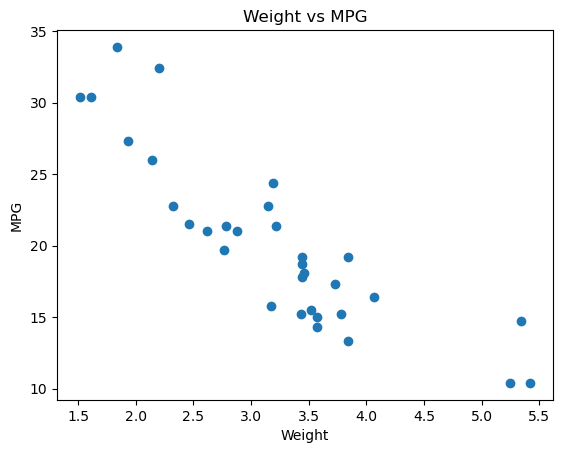

In [8]:
# Scatter plot of weight vs mpg
plt.scatter(df['wt'], df['mpg'])
plt.title("Weight vs MPG")
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.show()

# Observation: Cars having more weight tend to exhibit low MPG.

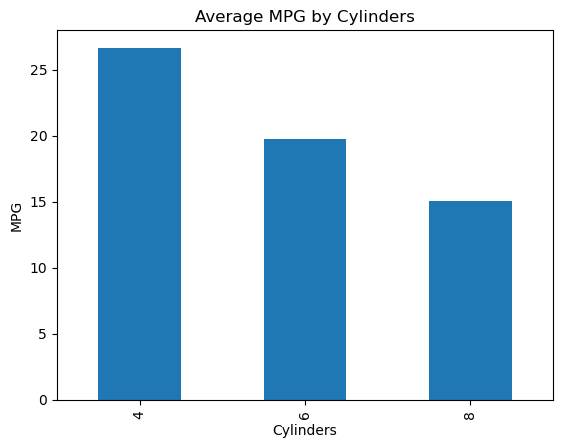

In [9]:
# Bar chart of average mpg by cylinders
df.groupby('cyl')['mpg'].mean().plot(kind='bar')
plt.title("Average MPG by Cylinders")
plt.xlabel("Cylinders")
plt.ylabel("MPG")
plt.show()

# Observation: Cars with 4 cylinders show higher mileages.

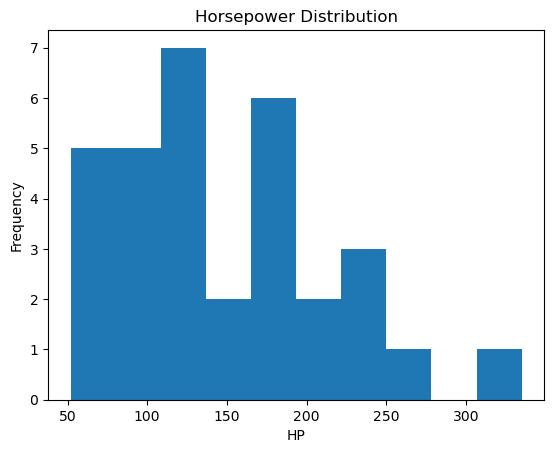

In [10]:
# Histogram of horsepower
plt.hist(df['hp'])
plt.title("Horsepower Distribution")
plt.xlabel("HP")
plt.ylabel("Frequency")
plt.show()

# Observation: Most of the cars stay in the moderate horsepower range.

# Five insights
    1. Cars with higher horsepower are known to have lower fuel efficiency.
    2. Manual transmission cars are comparatively lighter in weight than automatic cars.
    3. Heavier cars commonly show low mileages.
    4. 8 cylinders car has the highest horsepower.
    5. Cars with lower cylinder numbers such as 4, lead to higher fuel efficiency.

# Conclusion

In [ ]:
In this project, I analyzed the mtcars dataset using Python, Pandas, and Matplotlib. 
There are different factors that affect car performance, such as the number of cylinders, weight, and transmission type. 
The analysis showed that cars with fewer cylinders tend to have higher fuel efficiency. 
Manual transmission cars generally provide better mileage compared to automatic ones. 
Data visualizations through bar chart, scatter plot, and histogram also represent patterns and relationships. 
Overall, this project demonstrates how data analysis can provide useful insights for decision-making.